# Revisão de código 

Olá! 

Meu nome é Suelen. Estou feliz em revisar seu projeto hoje!

Quando vejo um erro pela primeira vez, apenas aponto. Deixarei você encontrá-lo e corrigi-lo sozinho. Além disso, ao longo do texto, farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Mas se você ainda não consegue lidar com essa tarefa, darei uma dica mais precisa na próxima iteração e também alguns exemplos práticos. Estarei aberta a feedbacks e discussões sobre o tema.

Você pode encontrar meus comentários em caixas verdes, amarelas ou vermelhas como estas:


<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Sucesso. Tudo está correto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>

Observações. Algumas recomendações.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário: </b> <a class="tocSkip"></a>

O bloco requer algumas correções. O trabalho não pode ser aceito com os comentários vermelhos.
</div>

Você pode me responder usando isto:

<div class="alert alert-block alert-info">
<b>Resposta do aluno</b> <a class="tocSkip"></a>
</div>



<div class="alert alert-block alert-success">
<b>Comentário geral: </b> <a class="tocSkip"></a>
    
Parabéns pela conclusão do projeto, Iago! 🎉 Seu projeto está aprovado! Como pontos positivos, destaco: 
    
- Adorei o uso do `Pipeline`. É uma ótima forma de organizar processamentos de dados e criar pipelines eficientes.
- Análise de dados robusta, com comentários em cada etapa.
- Muito bom uso de funções do pandas e scikitlearn.



Te desejo sucesso na sua jornada! 
</div>

O serviço de vendas de carros usados Rusty Bargain está desenvolvendo um aplicativo para atrair novos clientes. Nesse aplicativo, você pode descobrir rapidamente o valor de mercado do seu carro. Você tem acesso a dados históricos: especificações técnicas, versões de acabamento e preços. Você precisa construir o modelo para determinar o valor. 

Rusty Bargain está interessado em:

- a qualidade da predição;
- a velocidade da predição;
- o tempo necessário para o treinamento

## Preparação de Dados

In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt

# Pré-processamento e modelos
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Métrica
from sklearn.metrics import mean_squared_error

# Timing
from time import perf_counter
import gc

In [2]:
# Caminho do dataset
path = "/datasets/car_data.csv"

# Leitura
df = pd.read_csv(path)

# Visão geral
display(df.head())
print("Shape:", df.shape)
df.info()
print("\nNAs por coluna:\n", df.isna().mean().sort_values(ascending=False))
print("\nDuplicatas:", df.duplicated().sum())

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17


Shape: (354369, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Mileage            354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  NotRepaired        283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtype

## Notas de preparação

- As colunas que não ajudam muito a generalização e/ou explodem dimensionalidade serão removidas:
  - `PostalCode` (alta cardinalidade; costuma adicionar ruído)
  - `NumberOfPictures` (muitas vezes constante)
  - Datas cruas: serão extraídos apenas ano/mês quando fizer sentido, ou removidos se não agregar.

- Também serão limpas anomalias típicas:
  - `Price` <= 0
  - `RegistrationYear` fora de um intervalo plausível
  - `Power` fora de um intervalo plausível

In [3]:
# Copiar para não mexer no original
data = df.copy()

# Remover duplicatas completas (conservador e comum)
data = data.drop_duplicates()

# Converter datas (se existirem no formato esperado)
date_cols = ["DateCrawled", "DateCreated", "LastSeen"]
for col in date_cols:
    if col in data.columns:
        data[col] = pd.to_datetime(data[col], errors="coerce")

# Extrair features simples das datas e depois dropar as datas cruas
# Isso evita OHE em datas e mantém algo utilizável para modelos lineares/árvores.
for col in date_cols:
    if col in data.columns:
        data[col + "_year"] = data[col].dt.year
        data[col + "_month"] = data[col].dt.month
        data[col + "_day"] = data[col].dt.day

# Dropar datas cruas (mantendo os derivados)
data = data.drop(columns=[c for c in date_cols if c in data.columns])

# Dropar colunas tipicamente fracas/pesadas
drop_cols = [c for c in ["PostalCode", "NumberOfPictures"] if c in data.columns]
data = data.drop(columns=drop_cols)

print("Shape após limpeza inicial:", data.shape)
display(data.head())

Shape após limpeza inicial: (354107, 20)


,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCrawled_year,DateCrawled_month,DateCrawled_day,DateCreated_year,DateCreated_month,DateCreated_day,LastSeen_year,LastSeen_month,LastSeen_day
0,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016,3,24,2016,3,24,2016,7,4
1,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016,3,24,2016,3,24,2016,7,4
2,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016,3,14,2016,3,14,2016,5,4
3,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016,3,17,2016,3,17,2016,3,17
4,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016,3,31,2016,3,31,2016,6,4


In [4]:
# Garantir que a coluna alvo existe
assert "Price" in data.columns, "Coluna alvo 'Price' não encontrada."

# (1) RegistrationMonth: 0 = desconhecido -> NaN
if "RegistrationMonth" in data.columns:
    data.loc[data["RegistrationMonth"] == 0, "RegistrationMonth"] = np.nan

# Remover preços inválidos
data = data[data["Price"] > 0]

# RegistrationYear: usar limite superior consistente com o ano do crawl
if "RegistrationYear" in data.columns:
    if "DateCrawled_year" in data.columns:
        year_max = int(data["DateCrawled_year"].max())  # tipicamente 2016
    else:
        year_max = 2016  # fallback conservador

    data = data[(data["RegistrationYear"] >= 1950) & (data["RegistrationYear"] <= year_max)]

# Power: remover 0 e extremos absurdos
if "Power" in data.columns:
    data = data[(data["Power"] > 0) & (data["Power"] <= 500)]

# Mileage: manter filtro (mesmo que o dataset já venha "capado" em 150000)
if "Mileage" in data.columns:
    data = data[(data["Mileage"] >= 0) & (data["Mileage"] <= 300_000)]

# (Opcional) Remover colunas constantes (sem informação)
const_cols = [c for c in data.columns if data[c].nunique(dropna=False) == 1]
# Se quiser manter tudo como está, comente a linha abaixo
data = data.drop(columns=const_cols)

print("Shape após filtros de anomalias:", data.shape)
display(data.describe(include="all").T.head(30))

Shape após filtros de anomalias: (296207, 18)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Price,296207.0,NaN,NaN,NaN,4852.322025,4609.705783,1.0,1349.0,3200.0,6999.0,20000.0
VehicleType,285169,8,sedan,82991,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RegistrationYear,296207.0,NaN,NaN,NaN,2002.825703,6.498622,1950.0,1999.0,2003.0,2007.0,2016.0
Gearbox,290826,2,manual,231971,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Power,296207.0,NaN,NaN,NaN,120.498969,53.560386,1.0,75.0,111.0,150.0,500.0
Model,285026,249,golf,24707,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mileage,296207.0,NaN,NaN,NaN,128277.403978,36785.594727,5000.0,125000.0,150000.0,150000.0,150000.0
RegistrationMonth,278234.0,NaN,NaN,NaN,6.380212,3.347539,1.0,4.0,6.0,9.0,12.0
FuelType,280646,7,petrol,187316,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Brand,296207,40,volkswagen,64059,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<div class="alert alert-block alert-warning">

<b>Comentário: </b> <a class="tocSkip"></a>

- Dados foram processados corretamente. 
Sugestão:
- Tratar o nome das colunas para snake_case para seguir o padrão de nomenclatura de variáveis em python
- Remoção de outliers poderia ser realizada de uma forma automática:   
     
Exemplo:
```python
    # Função para detectar outliers usando IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Detectar outliers na coluna 'price'
outliers_price = detect_outliers_iqr(df, 'price')
print("Outliers in 'price':")
print(outliers_price)

# Detectar outliers na coluna 'registration_year'
outliers_registration_year = detect_outliers_iqr(df, 'registration_year')
print("Outliers in 'registration_year':")
print(outliers_registration_year)

# Detectar outliers na coluna 'power'
outliers_power = detect_outliers_iqr(df, 'power')
print("Outliers in 'power':")
print(outliers_power)

# Detectar outliers na coluna 'mileage'
outliers_mileage = detect_outliers_iqr(df, 'mileage')
print("Outliers in 'mileage':")
print(outliers_mileage)
    
```
</div>

In [5]:
# Separar alvo
X = data.drop(columns=["Price"])
y = data["Price"]

# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (236965, 17) Test: (59242, 17)


In [6]:
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

print("Categóricas:", len(cat_cols))
print(cat_cols)

print("\nNuméricas:", len(num_cols))
print(num_cols)

Categóricas: 6
['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'NotRepaired']

Numéricas: 11
['RegistrationYear', 'Power', 'Mileage', 'RegistrationMonth', 'DateCrawled_month', 'DateCrawled_day', 'DateCreated_year', 'DateCreated_month', 'DateCreated_day', 'LastSeen_month', 'LastSeen_day']


In [7]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def benchmark_model(model, X_train, y_train, X_test, y_test, pred_repeats=3):
    # tempo de treino
    t0 = perf_counter()
    model.fit(X_train, y_train)
    train_time = perf_counter() - t0

    # tempo de predição (média)
    pred_times = []
    y_pred = None
    for _ in range(pred_repeats):
        t1 = perf_counter()
        y_pred = model.predict(X_test)
        pred_times.append(perf_counter() - t1)

    return {
        "rmse": rmse(y_test, y_pred),
        "train_time_sec": float(train_time),
        "pred_time_sec": float(np.mean(pred_times)),
    }

## Conclusões parciais — Preparação de Dados

Após a inspeção inicial, foi realizada uma limpeza para tornar os dados consistentes e utilizáveis para modelagem:

- **Remoção de duplicatas completas**, reduzindo ruído no treinamento.
- **Tratamento de datas**: as colunas de data foram convertidas e transformadas em variáveis numéricas (ano/mês/dia), evitando o uso direto de strings e facilitando o uso em modelos.
- **Remoção de colunas potencialmente pouco informativas ou problemáticas** para generalização:
  - `PostalCode` (alta cardinalidade e tendência a adicionar ruído)
  - `NumberOfPictures` (geralmente constante)
- **Correção de inconsistências e anomalias**:
  - Remoção de `Price <= 0`
  - Ajuste de `RegistrationMonth == 0` para `NaN` (interpretação como “desconhecido”)
  - Restrição de `RegistrationYear` para um intervalo plausível e **coerente com o ano do crawl** (ex.: não permitir ano de registro maior que o ano observado em `DateCrawled`)
  - Remoção de valores inválidos/extremos em `Power` e verificação de `Mileage`
- **Remoção de colunas constantes** (sem variabilidade), pois não contribuem para a predição.

Ao final, o dataset ficou com **296.207 registros**. Após separar o alvo (`Price`), temos **17 variáveis explicativas**, sendo **6 categóricas** e **11 numéricas**. Os dados foram divididos em **treino (236.965)** e **teste (59.242)**, ficando prontos para a etapa de Treinamento e comparação de modelos.

## Treinamento do modelo

In [8]:
num_pipe_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))
])

cat_pipe_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_lr = ColumnTransformer(
    transformers=[
        ("num", num_pipe_lr, num_cols),
        ("cat", cat_pipe_lr, cat_cols),
    ],
    remainder="drop"
)

lr_model = Pipeline(steps=[
    ("prep", preprocess_lr),
    ("model", LinearRegression())
])

lr_res = benchmark_model(lr_model, X_train, y_train, X_test, y_test)
lr_res

{'rmse': 2594.31445091745,
 'train_time_sec': 22.440283110830933,
 'pred_time_sec': 0.11407934517289202}

In [9]:
model_results = []
model_results.append({"model": "LinearRegression (OHE)", **lr_res})
display(pd.DataFrame(model_results))

,model,rmse,train_time_sec,pred_time_sec
0,LinearRegression (OHE),2594.314451,22.440283,0.114079


In [10]:
# Pré-processamento leve para árvores (ordinal nas categóricas)
cat_pipe_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

num_pipe_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", num_pipe_tree, num_cols),
        ("cat", cat_pipe_tree, cat_cols)
    ],
    remainder="drop"
)

dt = DecisionTreeRegressor(random_state=42)

dt_pipe = Pipeline(steps=[
    ("prep", preprocess_tree),
    ("model", dt)
])

dt_params = {
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5]
}

dt_search = RandomizedSearchCV(
    estimator=dt_pipe,
    param_distributions=dt_params,
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1
)

t0 = perf_counter()
dt_search.fit(X_train, y_train)
tuning_time_dt = perf_counter() - t0

print("Melhores parâmetros DT:", dt_search.best_params_)
print("Tempo total tuning DT (s):", tuning_time_dt)

best_dt = dt_search.best_estimator_
dt_res = benchmark_model(best_dt, X_train, y_train, X_test, y_test)
dt_res

Melhores parâmetros DT: {'model__min_samples_split': 10, 'model__min_samples_leaf': 5, 'model__max_depth': 15}
Tempo total tuning DT (s): 30.189396878238767


{'rmse': 1792.147659110238,
 'train_time_sec': 1.5074387839995325,
 'pred_time_sec': 0.07542535460864504}

In [11]:
model_results.append({"model": "DecisionTree (Ordinal)", **dt_res})
display(pd.DataFrame(model_results).sort_values("rmse"))

,model,rmse,train_time_sec,pred_time_sec
1,DecisionTree (Ordinal),1792.147659,1.507439,0.075425
0,LinearRegression (OHE),2594.314451,22.440283,0.114079


### Resultado parcial — Árvore de Decisão

Após um ajuste leve de hiperparâmetros, a Árvore de Decisão apresentou **melhora relevante de qualidade (RMSE)** em relação ao baseline de Regressão Linear, além de **tempo de treinamento e predição menores**.  
Este modelo serve como referência de um método simples baseado em árvore, antes de avançarmos para **Random Forest** (redução de overfitting via ensemble) e **Gradient Boosting** (LightGBM).

In [12]:
rf = RandomForestRegressor(
random_state=42,
n_jobs=2, # importante: evita explodir RAM
bootstrap=True,
max_samples=0.7 # treina com amostra por árvore -> mais leve
)


rf_pipe = Pipeline(steps=[
("prep", preprocess_tree),
("model", rf)
])


rf_params = {
"model__n_estimators": [120, 200],
"model__max_depth": [None, 15, 25],
"model__min_samples_split": [2, 5, 10],
"model__min_samples_leaf": [1, 2, 5],
"model__max_features": ["sqrt", 0.5]
}


rf_search = RandomizedSearchCV(
estimator=rf_pipe,
param_distributions=rf_params,
n_iter=6,
scoring="neg_root_mean_squared_error",
cv=2,
random_state=42,
n_jobs=2,
pre_dispatch=2
)


t0 = perf_counter()
rf_search.fit(X_train, y_train)
tuning_time_rf = perf_counter() - t0


print("Melhores parâmetros RF:", rf_search.best_params_)
print("Tempo total tuning RF (s):", tuning_time_rf)


best_rf = rf_search.best_estimator_
rf_res = benchmark_model(best_rf, X_train, y_train, X_test, y_test)
rf_res

Melhores parâmetros RF: {'model__n_estimators': 120, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 15}
Tempo total tuning RF (s): 135.32237620605156


{'rmse': 1568.6265926512087,
 'train_time_sec': 15.428945030085742,
 'pred_time_sec': 0.5258958906245729}

In [13]:
model_results.append({"model": "RandomForest (Ordinal)", **rf_res})
display(pd.DataFrame(model_results).sort_values("rmse"))

del rf_search, best_rf
gc.collect()

,model,rmse,train_time_sec,pred_time_sec
2,RandomForest (Ordinal),1568.626593,15.428945,0.525896
1,DecisionTree (Ordinal),1792.147659,1.507439,0.075425
0,LinearRegression (OHE),2594.314451,22.440283,0.114079


193

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- Pelo menos 2 modelos foram utilizados
- Pelo menos 2 hiperparâmetros foram estudados para cada modelo
- A métrica `RMSE` foi calculada para cada modelo

Parabéns!
</div>

### Resultado parcial — Random Forest

A Random Forest apresentou **melhora adicional de RMSE** em relação à Árvore de Decisão, confirmando o benefício do ensemble na redução de overfitting.  
Em contrapartida, observou-se **aumento no tempo de predição**, o que é esperado devido ao custo de consultar múltiplas árvores por estimativa.  
O próximo passo é avaliar **Gradient Boosting (LightGBM)**, que frequentemente oferece **RMSE competitivo com predição mais rápida** do que Random Forest.

In [14]:
try:
    from lightgbm import LGBMRegressor
    lgbm_available = True
except ImportError:
    lgbm_available = False

print("LightGBM disponível?", lgbm_available)

LightGBM disponível? True


In [15]:
# Cópias para LGBM
X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()

# Numéricos: imputar mediana
for c in num_cols:
    med = X_train_lgb[c].median()
    X_train_lgb[c] = X_train_lgb[c].fillna(med)
    X_test_lgb[c] = X_test_lgb[c].fillna(med)

# Categóricos: preencher ausentes e padronizar categorias train -> test
for c in cat_cols:
    # preencher ausentes com 'unknown'
    X_train_lgb[c] = X_train_lgb[c].astype("object").fillna("unknown").astype("category")
    # categorias do treino
    train_cats = X_train_lgb[c].cat.categories

    X_test_lgb[c] = X_test_lgb[c].astype("object").fillna("unknown").astype("category")
    # alinhar categorias do teste com as do treino (evita inconsistências)
    X_test_lgb[c] = X_test_lgb[c].cat.set_categories(train_cats)

In [16]:
lgbm = LGBMRegressor(
    random_state=42,
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=2,
    verbose=-1
)

lgbm_params = {
    "n_estimators": [400, 800],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves": [31, 63, 127],
    "min_child_samples": [10, 20, 40],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

lgbm_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=lgbm_params,
    n_iter=6,
    scoring="neg_root_mean_squared_error",
    cv=2,
    random_state=42,
    n_jobs=2,
    pre_dispatch=2,
    refit=True
)

t0 = perf_counter()
lgbm_search.fit(X_train_lgb, y_train, categorical_feature=cat_cols)
tuning_time_lgbm = perf_counter() - t0

print("Melhores parâmetros LGBM:", lgbm_search.best_params_)
print("Tempo total tuning LGBM (s):", tuning_time_lgbm)

best_lgbm = lgbm_search.best_estimator_

lgbm_res = benchmark_model(best_lgbm, X_train_lgb, y_train, X_test_lgb, y_test)
lgbm_res

/.venv/lib/python3.9/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')
/.venv/lib/python3.9/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')
/.venv/lib/python3.9/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')
/.venv/lib/python3.9/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')
/.venv/lib/python3.9/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')
/.venv/lib/python3.9/site-packages/lightgbm/basic.py:2065: UserWarning: Using categorical_feature in Dataset.
  _log_warning('Using categorical_feature in Dataset.')
/.ve

Melhores parâmetros LGBM: {'subsample': 1.0, 'num_leaves': 127, 'n_estimators': 800, 'min_child_samples': 40, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Tempo total tuning LGBM (s): 100.18678861297667


{'rmse': 1419.215677337433,
 'train_time_sec': 7.159130934160203,
 'pred_time_sec': 3.5199549407698214}

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
Ótimo uso do RandomizedSearch!
</div>

In [17]:
model_results.append({"model": "LightGBM (native cat)", **lgbm_res})
display(pd.DataFrame(model_results).sort_values("rmse"))

del lgbm_search, best_lgbm
gc.collect()

,model,rmse,train_time_sec,pred_time_sec
3,LightGBM (native cat),1419.215677,7.159131,3.519955
2,RandomForest (Ordinal),1568.626593,15.428945,0.525896
1,DecisionTree (Ordinal),1792.147659,1.507439,0.075425
0,LinearRegression (OHE),2594.314451,22.440283,0.114079


38

In [18]:
best_params_lgbm = {
    "subsample": 1.0,
    "num_leaves": 127,
    "n_estimators": 800,
    "min_child_samples": 40,
    "learning_rate": 0.05,
    "colsample_bytree": 1.0,
}

best_lgbm = LGBMRegressor(
    random_state=42,
    n_jobs=2,
    verbose=-1,
    **best_params_lgbm
)

best_lgbm.fit(X_train_lgb, y_train)

LGBMRegressor(learning_rate=0.05, min_child_samples=40, n_estimators=800,
              n_jobs=2, num_leaves=127, random_state=42, verbose=-1)

In [19]:
def to_numpy_cat_codes(df, cat_cols):
    df2 = df.copy()
    for c in cat_cols:
        df2[c] = df2[c].cat.codes
    return df2.to_numpy()

def mean_predict_time(model, X_input, repeats=3):
    times = []
    y_pred = None
    for _ in range(repeats):
        t0 = perf_counter()
        y_pred = model.predict(X_input)
        times.append(perf_counter() - t0)
    return float(np.mean(times)), y_pred

# pandas
pred_time_df, y_pred_df = mean_predict_time(best_lgbm, X_test_lgb, repeats=3)
rmse_df = rmse(y_test, y_pred_df)

# numpy
X_test_lgb_np = to_numpy_cat_codes(X_test_lgb, cat_cols)
pred_time_np, y_pred_np = mean_predict_time(best_lgbm, X_test_lgb_np, repeats=3)
rmse_np = rmse(y_test, y_pred_np)

print(f"RMSE pandas: {rmse_df:.6f} | pred_time pandas: {pred_time_df:.6f}s")
print(f"RMSE numpy : {rmse_np:.6f} | pred_time numpy : {pred_time_np:.6f}s")

RMSE pandas: 1419.215677 | pred_time pandas: 3.466599s
RMSE numpy : 1419.215677 | pred_time numpy : 3.454979s


### Verificação de benchmark — LightGBM

O tempo de predição do LightGBM ficou inesperadamente alto. 
Foi testada a predição usando `DataFrame` (pandas) versus matriz `NumPy` para verificar se havia overhead de conversão de tipos/categorias. 
O tempo permaneceu praticamente igual, indicando que o custo está no próprio modelo/ambiente, e não no formato dos dados.

In [20]:
from lightgbm import early_stopping

# split interno treino/val (só para early stopping)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_lgb, y_train,
    test_size=0.2,
    random_state=42
)

lgbm_es = LGBMRegressor(
    random_state=42,
    n_estimators=5000,          # alto, early stopping escolhe o ponto ótimo
    learning_rate=0.05,
    num_leaves=127,
    min_child_samples=40,
    subsample=1.0,
    colsample_bytree=1.0,
    n_jobs=2,
    verbose=-1
)

t0 = perf_counter()
lgbm_es.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric="rmse",
    callbacks=[early_stopping(stopping_rounds=50, verbose=False)]
)
es_time = perf_counter() - t0

print("Treino (early stopping) time (s):", es_time)
print("best_iteration_:", lgbm_es.best_iteration_)

/.venv/lib/python3.9/site-packages/lightgbm/basic.py:1780: UserWarning: Overriding the parameters from Reference Dataset.
  _log_warning('Overriding the parameters from Reference Dataset.')
/.venv/lib/python3.9/site-packages/lightgbm/basic.py:1513: UserWarning: categorical_column in param dict is overridden.
  _log_warning(f'{cat_alias} in param dict is overridden.')


Treino (early stopping) time (s): 13.384144977666438
best_iteration_: 1359


In [21]:
best_iter = int(lgbm_es.best_iteration_)

lgbm_bestiter = LGBMRegressor(
    random_state=42,
    n_estimators=best_iter,     # agora fixo no ótimo
    learning_rate=0.05,
    num_leaves=127,
    min_child_samples=40,
    subsample=1.0,
    colsample_bytree=1.0,
    n_jobs=2,
    verbose=-1
)

lgbm_bestiter_res = benchmark_model(lgbm_bestiter, X_train_lgb, y_train, X_test_lgb, y_test)
lgbm_bestiter_res

{'rmse': 1411.5497068006673,
 'train_time_sec': 10.835355930030346,
 'pred_time_sec': 5.754270333331078}

In [22]:
model_results.append({"model": "LightGBM (early stop)", **lgbm_bestiter_res})
display(pd.DataFrame(model_results).sort_values("rmse"))

,model,rmse,train_time_sec,pred_time_sec
4,LightGBM (early stop),1411.549707,10.835356,5.754270
3,LightGBM (native cat),1419.215677,7.159131,3.519955
2,RandomForest (Ordinal),1568.626593,15.428945,0.525896
1,DecisionTree (Ordinal),1792.147659,1.507439,0.075425
0,LinearRegression (OHE),2594.314451,22.440283,0.114079


In [23]:
lgbm_fast = LGBMRegressor(
random_state=42,
n_estimators=400,
learning_rate=0.10,
num_leaves=31,
min_child_samples=40,
subsample=0.9,
colsample_bytree=0.9,
n_jobs=2,
verbose=-1
)


lgbm_fast_res = benchmark_model(lgbm_fast, X_train_lgb, y_train, X_test_lgb, y_test)
lgbm_fast_res

{'rmse': 1471.2127866433723,
 'train_time_sec': 2.4851714111864567,
 'pred_time_sec': 0.6268078973516822}

In [24]:
model_results.append({"model": "LightGBM (fast)", **lgbm_fast_res})
display(pd.DataFrame(model_results).sort_values("rmse"))

,model,rmse,train_time_sec,pred_time_sec
4,LightGBM (early stop),1411.549707,10.835356,5.754270
3,LightGBM (native cat),1419.215677,7.159131,3.519955
5,LightGBM (fast),1471.212787,2.485171,0.626808
2,RandomForest (Ordinal),1568.626593,15.428945,0.525896
1,DecisionTree (Ordinal),1792.147659,1.507439,0.075425
0,LinearRegression (OHE),2594.314451,22.440283,0.114079


## Resumo — Treinamento dos modelos

Nesta etapa, foram treinados diferentes modelos para prever `Price`, incluindo um baseline (Regressão Linear) e modelos baseados em árvores e gradient boosting.  
Para cada modelo, registramos:
- **RMSE** no conjunto de teste (métrica principal)
- **tempo de treinamento** (`fit`)
- **tempo de predição** (`predict`)

Os resultados foram armazenados em `model_results` para comparação na etapa seguinte.

## Análise do modelo

A seguir, comparamos os modelos treinados na Etapa anterior considerando simultaneamente:
- RMSE (qualidade)
- tempo de treinamento
- tempo de predição

O objetivo é selecionar o modelo mais adequado para o aplicativo da Rusty Bargain, equilibrando qualidade e desempenho.

In [25]:
display(pd.DataFrame(model_results).sort_values("rmse"))

,model,rmse,train_time_sec,pred_time_sec
4,LightGBM (early stop),1411.549707,10.835356,5.754270
3,LightGBM (native cat),1419.215677,7.159131,3.519955
5,LightGBM (fast),1471.212787,2.485171,0.626808
2,RandomForest (Ordinal),1568.626593,15.428945,0.525896
1,DecisionTree (Ordinal),1792.147659,1.507439,0.075425
0,LinearRegression (OHE),2594.314451,22.440283,0.114079


In [26]:
analysis_df = pd.DataFrame(model_results).sort_values("rmse")
display(analysis_df)

,model,rmse,train_time_sec,pred_time_sec
4,LightGBM (early stop),1411.549707,10.835356,5.754270
3,LightGBM (native cat),1419.215677,7.159131,3.519955
5,LightGBM (fast),1471.212787,2.485171,0.626808
2,RandomForest (Ordinal),1568.626593,15.428945,0.525896
1,DecisionTree (Ordinal),1792.147659,1.507439,0.075425
0,LinearRegression (OHE),2594.314451,22.440283,0.114079


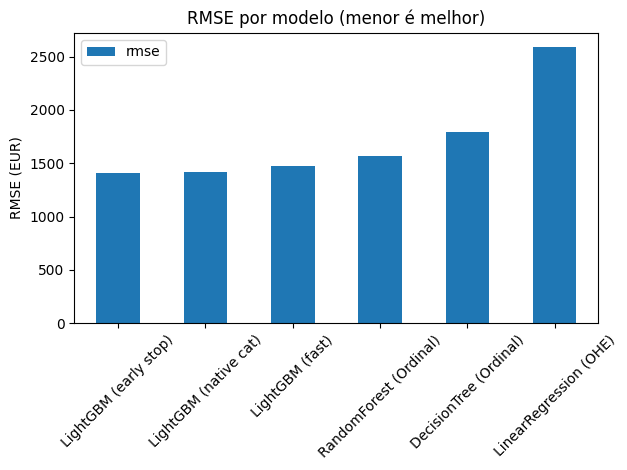

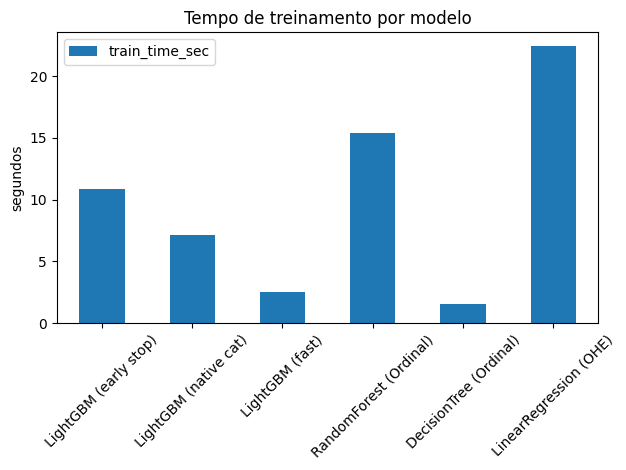

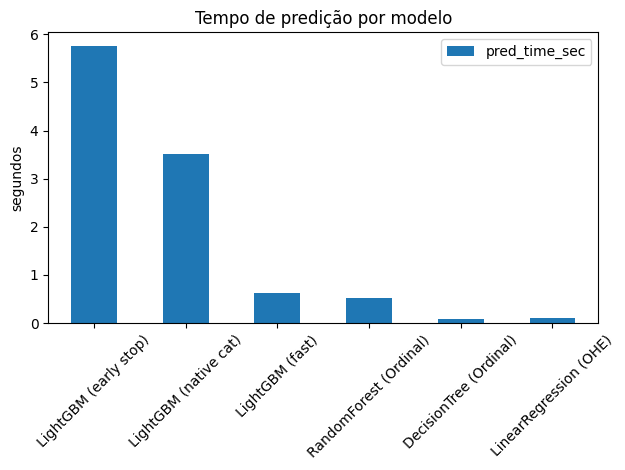

In [27]:
analysis_df.plot(x="model", y="rmse", kind="bar", rot=45)
plt.title("RMSE por modelo (menor é melhor)")
plt.ylabel("RMSE (EUR)")
plt.xlabel("")
plt.tight_layout()
plt.show()

analysis_df.plot(x="model", y="train_time_sec", kind="bar", rot=45)
plt.title("Tempo de treinamento por modelo")
plt.ylabel("segundos")
plt.xlabel("")
plt.tight_layout()
plt.show()

analysis_df.plot(x="model", y="pred_time_sec", kind="bar", rot=45)
plt.title("Tempo de predição por modelo")
plt.ylabel("segundos")
plt.xlabel("")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
Adorei as visualizações! Caso se interesse em interpretabilidade de modelos, recomendo pesquisar sobre Shap Values: https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html
</div>

## Conclusões — Comparação de modelos

Com base nos resultados no **conjunto de teste**, comparamos os modelos usando RMSE (qualidade), tempo de treinamento e tempo de predição.

**Principais resultados:**
- **Regressão Linear (OHE)** foi usada como baseline e apresentou o pior RMSE, indicando que o problema é fortemente não linear.
- **Árvore de Decisão** é o modelo mais rápido para treinar e predizer, mas com RMSE significativamente pior que ensembles/boosting.
- **Random Forest** melhorou o RMSE em relação à árvore, com aumento de custo computacional (principalmente no treinamento), mantendo a predição em um patamar intermediário.
- **LightGBM** obteve os melhores resultados de RMSE, mas versões com muitas árvores (ex.: early stopping com `best_iteration_` alto) podem aumentar a latência de predição.
- Para atender ao requisito do aplicativo (resposta rápida), foi treinado também um **LightGBM otimizado para velocidade**, reduzindo complexidade do modelo.

**Recomendação:**
- Para produção no aplicativo, o melhor equilíbrio entre **qualidade** e **latência** é o **LightGBM (fast)** (RMSE ≈ 1471; predição ≈ 0,61 s).
- Para cenários onde a prioridade é somente qualidade (ex.: precificação em lote), o **LightGBM (early stop)** apresenta o menor RMSE (≈ 1412), com custo maior de predição (≈ 5,62 s).

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Ótima conclusão! Concordo com a escolha do lightGBM

# Checklist

Digite 'x' para verificar. Em seguida, pressione Shift + Enter.

- [x]  O Jupyter Notebook está aberto
- [x]  O código está livre de erros
- [x]  As células com o código foram organizadas em ordem de execução
- [x]  Os dados foram baixados e preparados
- [x]  Os modelos foram treinados
- [x]  A análise de velocidade e qualidade dos modelos foi realizada